# Check and process an image

**The job.** Take some images. Check each one is worth keeping. Process the good
ones. Say why the rest were skipped.

The check comes first for a reason. Resizing a blank image gives you a smaller
blank image, and everything downstream believes it worked.

**In:** three images we draw here.
**Out:** a report per image, plus processed copies.
**Files:** the originals, the processed versions, thumbnails, and report.json.

In [1]:
try:
    import browsergraph  # noqa: F401
except ImportError:
    %pip install -q "browsergraph @ git+https://github.com/aidonerightcorp/browsergraph.git"

import json, pathlib
from dataclasses import replace

from browsergraph import execute, viz
from browsergraph.compile import compile_route
from browsergraph.manifest import NodeManifest, PortSpec
from browsergraph.workbench import Edge, NodeCandidate, StageDefinition, WorkbenchDefinition

# A fresh folder each run. Left-over files from a previous run make the "what
# did this produce" list a lie, and that list is half the point here.
import shutil
WORK = pathlib.Path("work")
shutil.rmtree(WORK, ignore_errors=True)
WORK.mkdir()

# These come from the library rather than being redefined in every notebook.
# They used to be thirty lines pasted into each one, which meant anyone copying
# a notebook to start a project got helpers that did not exist in browsergraph.
from browsergraph.quick import chain, fanin, fanout, link, node, problems, step
from browsergraph.quick import graph as _graph
from browsergraph.quick import subgraph  # noqa: F401  (used by later notebooks)

# The notebooks kept the older names, and `build` also prints what is wrong
# rather than raising — in a notebook the complaint is the lesson.
stage = step

def build(title, task, stages, nodes, edges=()):
    bench = _graph(title, task, stages, nodes, edges)
    print("problems:", problems(bench) or "none")
    return bench

print("ready")

ready


## The input

Three images. One normal photo-ish gradient, one that is almost entirely one
colour, and one that is tiny. The last two should not pass.

In [2]:
import numpy as np
from PIL import Image

rng = np.random.default_rng(7)

def gradient(w, h):
    x = np.linspace(0, 255, w, dtype=np.uint8)
    base = np.tile(x, (h, 1))
    noise = rng.integers(0, 40, size=(h, w), dtype=np.uint8)
    rgb = np.dstack([base, np.roll(base, 40, axis=1), noise])
    return Image.fromarray(rgb.astype(np.uint8), "RGB")

sources = {}
sources["good.png"] = gradient(640, 400)
sources["blank.png"] = Image.fromarray(np.full((400, 640, 3), 250, np.uint8), "RGB")
sources["tiny.png"] = gradient(48, 30)

for name, img in sources.items():
    path = WORK / name
    img.save(path)
    print(f"  {name:<12} {img.size[0]:>4} x {img.size[1]:<4}  {path.stat().st_size:>7,} bytes")

  good.png      640 x 400   264,670 bytes
  blank.png     640 x 400     1,637 bytes
  tiny.png       48 x 30      1,757 bytes


## The steps

Load, measure, decide, process, save. The decide step splits into pass and fail
so the two paths are visible.

In [3]:
nodes = [
    node("load.folder", "image.read",    [],                    [("out", "Images")]),
    node("measure.px",  "image.measure", [("in", "Images")],    [("out", "Report")]),
    node("decide.keep", "image.decide",  [("in", "Report")],    [("keep", "Images"), ("skip", "Report")]),
    node("process.std", "image.process", [("in", "Images")],    [("out", "Images")]),
    node("save.images", "write",         [("in", "Images"), ("report", "Report")], [("out", "Receipt")],
         effects=("file.write",)),
]

stages = [
    stage("load",    "Load images",   [],                  [("out", "Images")],  "image.read",    ["load.folder"]),
    stage("measure", "Measure them",  [("in", "Images")],  [("out", "Report")],  "image.measure", ["measure.px"]),
    stage("decide",  "Keep or skip",  [("in", "Report")],  [("keep", "Images"), ("skip", "Report")], "image.decide", ["decide.keep"]),
    stage("process", "Process kept",  [("in", "Images")],  [("out", "Images")],  "image.process", ["process.std"]),
    stage("save",    "Save results",  [("in", "Images"), ("report", "Report")], [("out", "Receipt")], "write", ["save.images"]),
]

edges = [Edge("load", "measure"), Edge("measure", "decide"),
         Edge("decide", "process", from_port="keep"),
         Edge("process", "save", to_port="in"),
         Edge("decide", "save", from_port="skip", to_port="report")]

bench = build("Check and process images",
              "Check each image, process the good ones, say why the rest were skipped.",
              stages, nodes, edges)
print("layers:", bench.layers())

problems: none
layers: [['load'], ['measure'], ['decide'], ['process'], ['save']]


In [4]:
viz.dag(bench)

Figure(svg='<svg viewBox="0 0 1100 226" width="1100" height="226" style="max-width:none" role="img"><defs><marker id="bg69413744-arrow" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="7" markerHeight="7" orient="auto-start-end"><path d="M0,0 L10,5 L0,10 z" fill="#8a93a0"/></marker></defs><text x="153.0" y="44" text-anchor="middle" font-size="10" fill="#68737f">layer 0</text><g><rect x="60" y="74.0" width="186" height="52" rx="7" fill="#eef1f5" stroke="#8a93a0" stroke-width="1"/><text x="69" y="93.0" font-size="11.5" font-weight="700" fill="#22303f">Load images</text><text x="69" y="108.0" font-size="9.5" fill="#68737f">1 candidate</text></g><text x="363.0" y="44" text-anchor="middle" font-size="10" fill="#68737f">layer 1</text><g><rect x="270" y="74.0" width="186" height="52" rx="7" fill="#eef1f5" stroke="#8a93a0" stroke-width="1"/><text x="279" y="93.0" font-size="11.5" font-weight="700" fill="#22303f">Measure them</text><text x="279" y="108.0" font-size="9.5" fill="#68737f">1 candidate</text></g><text x="573.0" y="44" text-anchor="middle" font-size="10" fill="#68737f">layer 2</text><g><rect x="480" y="74.0" width="186" height="52" rx="7" fill="#eef1f5" stroke="#8a93a0" stroke-width="1"/><text x="489" y="93.0" font-size="11.5" font-weight="700" fill="#22303f">Keep or skip</text><text x="489" y="108.0" font-size="9.5" fill="#68737f">1 candidate</text></g><text x="783.0" y="44" text-anchor="middle" font-size="10" fill="#68737f">layer 3</text><g><rect x="690" y="74.0" width="186" height="52" rx="7" fill="#eef1f5" stroke="#8a93a0" stroke-width="1"/><text x="699" y="93.0" font-size="11.5" font-weight="700" fill="#22303f">Process kept</text><text x="699" y="108.0" font-size="9.5" fill="#68737f">1 candidate</text></g><text x="993.0" y="44" text-anchor="middle" font-size="10" fill="#68737f">layer 4</text><g><rect x="900" y="74.0" width="186" height="52" rx="7" fill="#eef1f5" stroke="#8a93a0" stroke-width="1"/><text x="909" y="93.0" font-size="11.5" font-weight="700" fill="#22303f">Save results</text><text x="909" y="108.0" font-size="9.5" fill="#68737f">1 candidate</text></g><path d="M246,100.0 C258.0,100.0 258.0,100.0 270,100.0" fill="none" stroke="#8a93a0" stroke-width="1.4" opacity=".75" marker-end="url(#bg69413744-arrow)"/><path d="M456,100.0 C468.0,100.0 468.0,100.0 480,100.0" fill="none" stroke="#8a93a0" stroke-width="1.4" opacity=".75" marker-end="url(#bg69413744-arrow)"/><path d="M666,100.0 C678.0,100.0 678.0,100.0 690,100.0" fill="none" stroke="#8a93a0" stroke-width="1.4" opacity=".75" marker-end="url(#bg69413744-arrow)"/><text x="678.0" y="95.0" text-anchor="middle" font-size="9" fill="#68737f">keep</text><path d="M876,100.0 C888.0,100.0 888.0,100.0 900,100.0" fill="none" stroke="#8a93a0" stroke-width="1.4" opacity=".75" marker-end="url(#bg69413744-arrow)"/><text x="888.0" y="95.0" text-anchor="middle" font-size="9" fill="#68737f">in</text><path d="M666,100.0 C783.0,100.0 783.0,100.0 900,100.0" fill="none" stroke="#8a93a0" stroke-width="1.4" opacity=".75" marker-end="url(#bg69413744-arrow)"/><text x="783.0" y="95.0" text-anchor="middle" font-size="9" fill="#68737f">report</text></svg>', title='Check and process images — shape', note='a chain. Boxes in the same layer are independent and may run together; every arrow is a typed port-to-port connection.', width=1100, height=226)

## The checks

Three numbers per image. Size, how much of the colour range is used, and how
many distinct colours there are. A near-blank image scores low on the last two
even though it is a perfectly valid PNG.

In [5]:
MIN_WIDTH, MIN_HEIGHT = 200, 200
MIN_SPREAD, MIN_COLOURS = 20.0, 50

def load_folder():
    return {name: Image.open(WORK / name).convert("RGB") for name in sources}

def measure_px(**kw):
    report = {}
    for name, img in kw["in"].items():
        array = np.asarray(img)
        report[name] = {
            "width": img.size[0], "height": img.size[1],
            "spread": float(array.std()),
            "colours": int(len(np.unique(array.reshape(-1, 3), axis=0))),
            "mean": float(array.mean()),
        }
    return report

def decide_keep(**kw):
    keep, skip = {}, {}
    for name, m in kw["in"].items():
        why = []
        if m["width"] < MIN_WIDTH or m["height"] < MIN_HEIGHT:
            why.append(f"too small ({m['width']}x{m['height']})")
        if m["spread"] < MIN_SPREAD:
            why.append(f"almost flat (spread {m['spread']:.1f})")
        if m["colours"] < MIN_COLOURS:
            why.append(f"only {m['colours']} colours")
        if why:
            skip[name] = dict(m, why="; ".join(why))
        else:
            keep[name] = Image.open(WORK / name).convert("RGB")
    return {"keep": keep, "skip": skip}

def process_std(**kw):
    """Two outputs per image: a web-sized copy and a thumbnail."""
    out = {}
    for name, img in kw["in"].items():
        big = img.copy(); big.thumbnail((320, 320))
        small = img.copy(); small.thumbnail((96, 96))
        out[f"web_{name}"] = big
        out[f"thumb_{name}"] = small
    return out

def save_images(workspace, **kw):
    written = []
    for name, img in kw["in"].items():
        path = workspace / name
        img.save(path)
        written.append(f"{name} {img.size[0]}x{img.size[1]}")
    (workspace / "report.json").write_text(json.dumps(kw["report"], indent=2))
    return {"written": written, "skipped": list(kw["report"])}

runtime = execute.Runtime({
    "load.folder": load_folder, "measure.px": measure_px,
    "decide.keep": decide_keep, "process.std": process_std,
    "save.images": save_images,
})

plan = compile_route(bench, {s.id: s.candidates[0] for s in bench.leaf_stages})
run = execute.run(plan, runtime, workspace=WORK)
print(run.text())

plan plan:0411cb810be9119e02ca4…
5 steps in 0.520s — ok
  ok   load             0.007s  load.folder
  ok   measure          0.486s  measure.px
  ok   decide           0.004s  decide.keep
  ok   process          0.003s  process.std
  ok   save             0.019s  save.images  [file.write]
  file /home/username/code_projects/repos/browsergraph/notebooks/work/report.json  343 bytes  sha256:3604e4c35…
  file /home/username/code_projects/repos/browsergraph/notebooks/work/thumb_good.png  3,605 bytes  sha256:6cd08f0b1…
  file /home/username/code_projects/repos/browsergraph/notebooks/work/web_good.png  53,135 bytes  sha256:1cf262adf…


## The numbers, and the decision they drove

In [6]:
measured = run.output("measure")
skipped = run.values[("decide", "skip")]
kept = run.values[("decide", "keep")]

print(f"{'image':<12}{'size':>11}{'spread':>9}{'colours':>9}   verdict")
for name, m in measured.items():
    verdict = "keep" if name in kept else "SKIP — " + skipped[name]["why"]
    print(f"{name:<12}{m['width']:>5}x{m['height']:<5}{m['spread']:>9.1f}{m['colours']:>9,}   {verdict}")

image              size   spread  colours   verdict
good.png      640x400       79.0   11,560   keep
blank.png     640x400        0.0        1   SKIP — almost flat (spread 0.0); only 1 colours
tiny.png       48x30        79.7    1,032   SKIP — too small (48x30)


The blank image is a real PNG of the right size. Only the spread and colour
count catch it. That is the check worth having: it fails the thing that looks
fine.

In [7]:
print("files written:")
for art in run.artifacts:
    print(f"  {art.path:<34} {art.bytes:>8,} bytes  {art.digest[:18]}…")

files written:
  /home/username/code_projects/repos/browsergraph/notebooks/work/report.json      343 bytes  sha256:3604e4c35c4…
  /home/username/code_projects/repos/browsergraph/notebooks/work/thumb_good.png    3,605 bytes  sha256:6cd08f0b11f…
  /home/username/code_projects/repos/browsergraph/notebooks/work/web_good.png   53,135 bytes  sha256:1cf262adf64…


In [8]:
# Where the time actually went. Colour carries the outcome: a step that was
# cached, one skipped by a branch and one that fell back to another candidate
# all "succeeded", and they are not the same thing.
viz.timeline(run, title='checking and processing an image')

Figure(svg='<svg viewBox="0 0 1000 276" width="1000" height="276" style="max-width:none" role="img"><text x="190" y="34" font-size="10.5" fill="#68737f">0s</text><text x="870" y="34" text-anchor="end" font-size="10.5" fill="#68737f">0.519s</text><line x1="190" y1="42" x2="870" y2="42" stroke="#dfe5ec" stroke-width="1"/><text x="176" y="90" text-anchor="end" font-size="11" font-weight="600" fill="#22303f">load</text><rect x="190.7" y="77" width="9.1" height="19" rx="4" fill="#1f8a4c" opacity=".78" stroke="#1f8a4c" stroke-width="1"><title>load.folder — ran, 7.0ms</title></rect><text x="208.8" y="91" font-size="10" fill="#68737f">7ms · ran</text><text x="176" y="120" text-anchor="end" font-size="11" font-weight="600" fill="#22303f">measure</text><rect x="199.8" y="107" width="635.7" height="19" rx="4" fill="#1f8a4c" opacity=".78" stroke="#1f8a4c" stroke-width="1"><title>measure.px — ran, 485.5ms</title></rect><text x="844.5" y="121" font-size="10" fill="#68737f">486ms · ran</text><text x="176" y="150" text-anchor="end" font-size="11" font-weight="600" fill="#22303f">decide</text><rect x="835.6" y="137" width="5.0" height="19" rx="4" fill="#1f8a4c" opacity=".78" stroke="#1f8a4c" stroke-width="1"><title>decide.keep — ran, 3.9ms</title></rect><text x="849.7" y="151" font-size="10" fill="#68737f">4ms · ran</text><text x="176" y="180" text-anchor="end" font-size="11" font-weight="600" fill="#22303f">process</text><rect x="840.7" y="167" width="4.0" height="19" rx="4" fill="#1f8a4c" opacity=".78" stroke="#1f8a4c" stroke-width="1"><title>process.std — ran, 3.1ms</title></rect><text x="853.7" y="181" font-size="10" fill="#68737f">3ms · ran</text><text x="176" y="210" text-anchor="end" font-size="11" font-weight="600" fill="#22303f">save</text><rect x="844.8" y="197" width="25.2" height="19" rx="4" fill="#1f8a4c" opacity=".78" stroke="#1f8a4c" stroke-width="1"><title>save.images — ran, 19.3ms</title></rect><text x="879.0" y="211" font-size="10" fill="#68737f">19ms · ran</text><rect x="190" y="244" width="10" height="10" rx="2" fill="#c0392b" opacity=".78"/><text x="205" y="253" font-size="10" fill="#68737f">failed</text> <rect x="286" y="244" width="10" height="10" rx="2" fill="#68737f" opacity=".78"/><text x="301" y="253" font-size="10" fill="#68737f">skipped</text> <rect x="382" y="244" width="10" height="10" rx="2" fill="#2d6cb5" opacity=".78"/><text x="397" y="253" font-size="10" fill="#68737f">cached</text> <rect x="478" y="244" width="10" height="10" rx="2" fill="#c98a2b" opacity=".78"/><text x="493" y="253" font-size="10" fill="#68737f">fell back</text> <rect x="574" y="244" width="10" height="10" rx="2" fill="#1f8a4c" opacity=".78"/><text x="589" y="253" font-size="10" fill="#68737f">ran</text></svg>', title='checking and processing an image', note='Bars are placed at the time each step began.', width=1000, height=276)

## Look at what came out

web_good.png


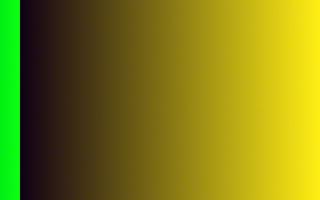

In [9]:
from IPython.display import display
for name in sorted(p.name for p in WORK.glob("web_*.png")):
    print(name)
    display(Image.open(WORK / name))